# Network basics and representation

In this notebook, we will learn the basics of networkx, the python package we will use to read and characterize real networks.
1. [Codes to set up the notebook](#section1)
2. [Synthetic network](#section2)
3. [An example with a real network](#section3)


## 1. Codes to set up the notebook for the simulation

<a id='section1'></a>

### Code to grant access to the Google Drive folder

This command will be recurrent in all the notebooks and will allow us to set the working directory in our Google drive folder (run only in case you are working with Google Collab and Google Drive)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir("/content/drive/MyDrive/Lab_visualization/Notebooks")

Mounted at /content/drive


### Code to import the needed modules/packages to run the notebook

In [1]:
import pandas as pd ## dataframes
import numpy as np ## Mathematical operations
import matplotlib.pyplot as plt ## Representation
from matplotlib import rcParams
from matplotlib import colors
import random as random
import networkx as nx ## Network tools

<a name='section2'></a>


## 2. Synthetic network
<a id='section2'></a>


### In this section, we explain the very basics of networkx and illustrate the use in a toy synthetic network.


First thing we will create a very simple network with 5 nodes, so we can learn the basic commands of networkx to

In [3]:
G=nx.Graph() ## A network is encoded in networkx as a Graph class

In [4]:
G

Now we add 5 nodes

In [5]:
### First option: Define the list of nodes and add them one by one
nodes=[i+1 for i in range(5)]
for node in nodes:
    G.add_node(node)


The following command show the list of nodes in the network

In [6]:
list(G.nodes())

[1, 2, 3, 4, 5]

In [7]:
G=nx.Graph()
### Second option: Add a list a nodes through an iterable function
G.add_nodes_from(range(1,6))

In [8]:
list(G.nodes())

[1, 2, 3, 4, 5]

Now we will add some edges between these nodes

In [9]:
G.add_edges_from([(1,2), (1,3), (2,3), (3,4), (3,5), (4,5)])

To show the list of edges

In [10]:
list(G.edges())

[(1, 2), (1, 3), (2, 3), (3, 4), (3, 5), (4, 5)]

Now we will see how to compute the number of nodes $N$ and edges $E$ in the network

In [11]:
print('The number of nodes in the network is:',G.number_of_nodes())
print('The number of edges in the network is:',G.number_of_edges())

The number of nodes in the network is: 5
The number of edges in the network is: 6


Networkx also allows drawing the network to visualize it

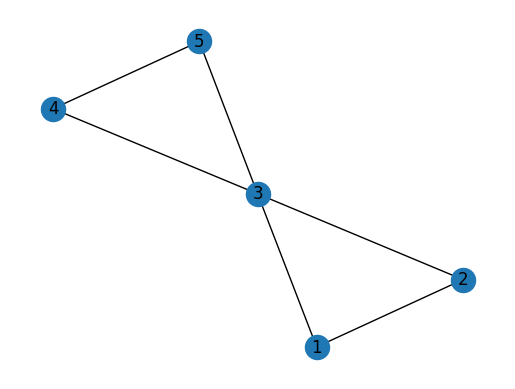

In [12]:
nx.draw_networkx(G,with_labels=True)
plt.box(False)

We can also compute the degree of each node with networkx

In [13]:
degree=dict(G.degree())
print(degree)

{1: 2, 2: 2, 3: 4, 4: 2, 5: 2}


The output of the previous cell is a dictionary. To access to the specific degree of a node, we should use the label of the node. For instance, to obtain the degree of node '2':

In [14]:
print('The degree of node 2 is',degree[2])
print('The degree of node 2 is',G.degree(2))

The degree of node 2 is 2
The degree of node 2 is 2


We can use the degree of the network to set the size of the nodes in the network

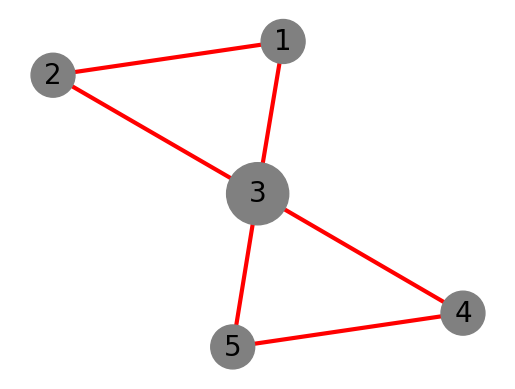

In [15]:
### We create a list with the size of nodes assuming that them to be proportional to the degrees
sizes=[500*degree[node] for node in G.nodes()]
nx.draw_networkx(G,node_size=sizes,edge_color='red',node_color='grey',width=3,with_labels=True,font_size=20) ## We can also modify the color of edges, their width, labels etc.
plt.box(False)

Get the adjacency matrix of a network

In [17]:
Araw=nx.adjacency_matrix(G) ### Get adjacency matrix

A=Araw.todense() ### Convert it into a matrix form

A2=np.matmul(A,A) ### Square of the adjacency matrix

The elements of $A^2$ tell us the number of walks of length 2 connecting two nodes in the network.

Let us create another simple network:

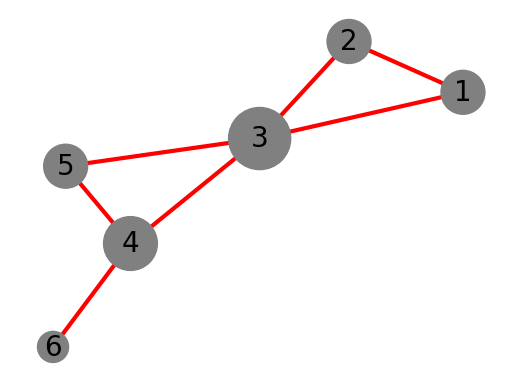

In [18]:
Gnew=G.copy()

Gnew.add_node(6)
Gnew.add_edge(4,6)


sizes=[500*Gnew.degree(node) for node in Gnew.nodes()]
nx.draw_networkx(Gnew,node_size=sizes,edge_color='red',node_color='grey',width=3,with_labels=True,font_size=20) ## We can also modify the color of edges, their width, labels etc.
plt.box(False)


Let us explore the meaning of the different powers of the adjacency matrix

In [19]:
Araw=nx.adjacency_matrix(Gnew) ### Get adjacency matrix

A=Araw.todense() ### Convert it into a matrix form

A2=np.matmul(A,A) ### Square of the adjacency matrix

A3=np.matmul(A2,A) ### Third power of the adjacency matrix

In [21]:
print('A\n',A)
print('A2\n',A2)
print('A3\n',A3)

A
 [[0 1 1 0 0 0]
 [1 0 1 0 0 0]
 [1 1 0 1 1 0]
 [0 0 1 0 1 1]
 [0 0 1 1 0 0]
 [0 0 0 1 0 0]]
A2
 [[2 1 1 1 1 0]
 [1 2 1 1 1 0]
 [1 1 4 1 1 1]
 [1 1 1 3 1 0]
 [1 1 1 1 2 1]
 [0 0 1 0 1 1]]
A3
 [[2 3 5 2 2 1]
 [3 2 5 2 2 1]
 [5 5 4 6 5 1]
 [2 2 6 2 4 3]
 [2 2 5 4 2 1]
 [1 1 1 3 1 0]]


## Real networks
<a id='section3'></a>

### The network of collaborations among network scientists.

First, we load the data. The following cell will not be valid for all the datasets as the way of loading data into networkx depends on the format of the network file

In [23]:
G=nx.read_edgelist('../Datasets/ca-netscience.edges')

**Warning**: Network repository usually includes .mtx files. To make the previous line work, you should ensure that the first line starts with '%%' and the second line just contains three number without any '%'.

Let us obtain the number of nodes and edges of the network:

In [24]:
print('The number of nodes in the network is:',G.number_of_nodes())
print('The number of edges in the network is:',G.number_of_edges())

The number of nodes in the network is: 379
The number of edges in the network is: 914


Let us represent the network. For this purpose, we will set the position of the nodes based on a layout algorithm. Let's explore three of them: random, circular, kamada-kawai

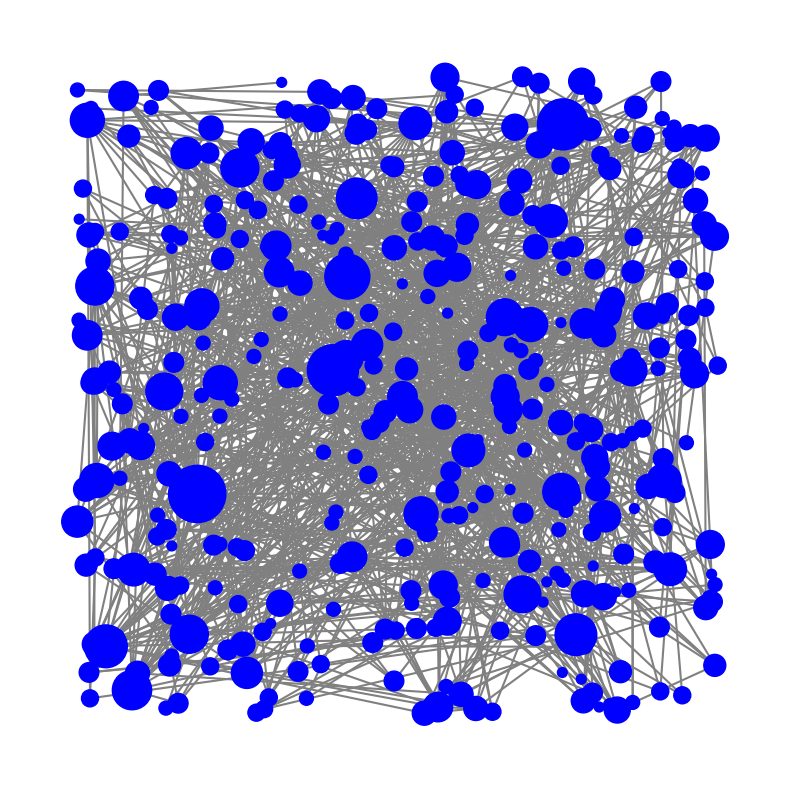

In [25]:
### We fix the position of the nodes

positions=nx.random_layout(G,seed=1)

## Size proportional to degree again
sizes=[50*G.degree(node) for node in G.nodes()]

## We represent the network fixing the positions.
fig=plt.figure(figsize=(10,10))
nx.draw_networkx(G,node_size=sizes,pos=positions,edge_color='grey',node_color='blue',width=1.5,with_labels=False,font_size=20)
plt.box(False)


We get little information from the random layout

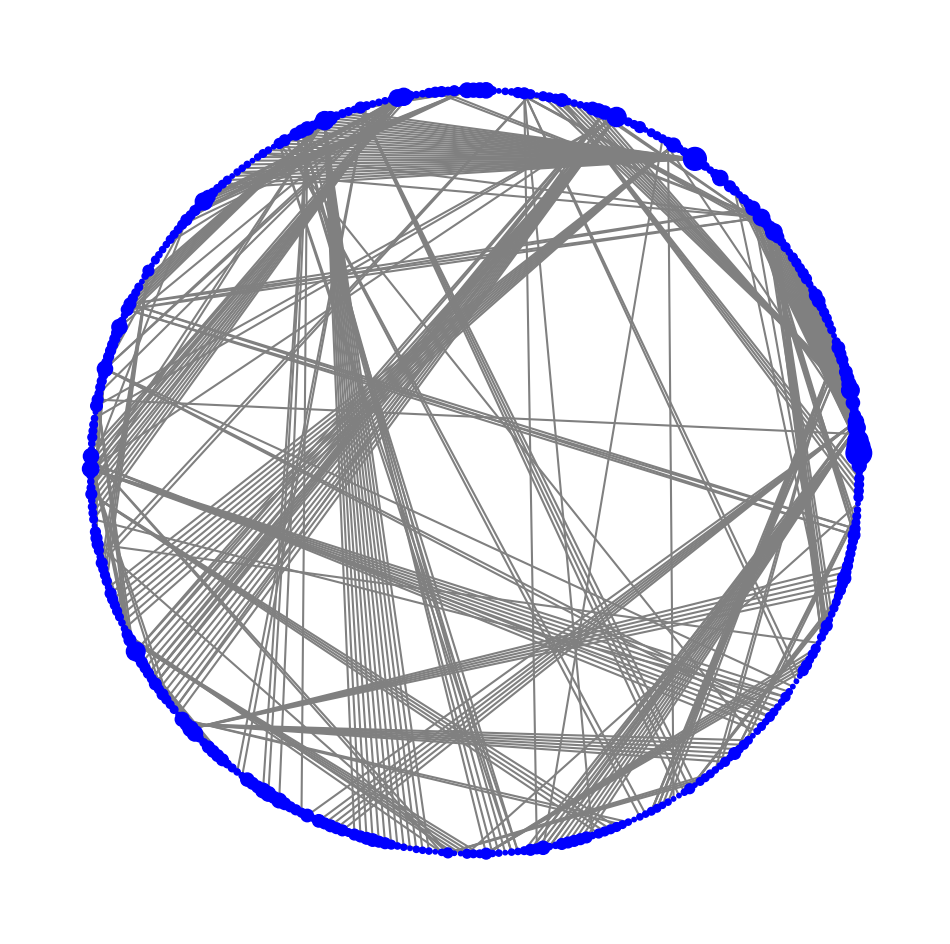

In [29]:
### We fix the position of the nodes

positions=nx.circular_layout(G)

## Size proportional to degree again
sizes=[10*G.degree(node) for node in G.nodes()]

## We represent the network fixing the positions.
fig=plt.figure(figsize=(12,12))
nx.draw_networkx(G,node_size=sizes,pos=positions,edge_color='grey',node_color='blue',width=1.5,with_labels=False,font_size=20)
plt.box(False)

Circular layout does not work either

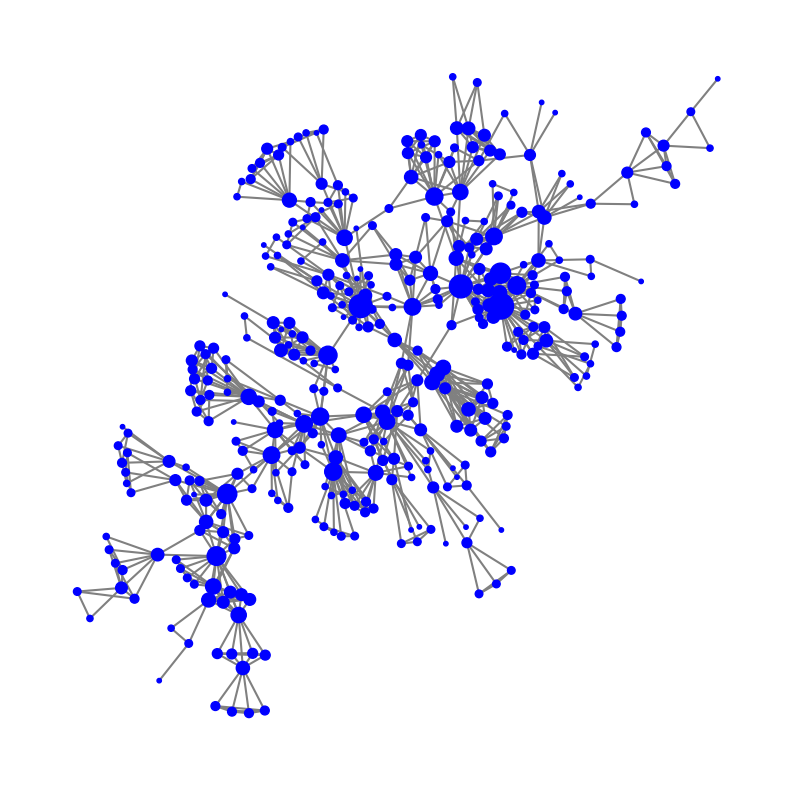

In [30]:
### We fix the position of the nodes

positions=nx.kamada_kawai_layout(G)

## Size proportional to degree again
sizes=[10*G.degree(node) for node in G.nodes()]

## We represent the network fixing the positions.
fig=plt.figure(figsize=(10,10))
nx.draw_networkx(G,node_size=sizes,pos=positions,edge_color='grey',node_color='blue',width=1.5,with_labels=False,font_size=20)
plt.box(False)

Positioning algorithms allows locating regions that are tightly linked closer in space. Some examples: kamada-kawai layout, spring layout

### Airport mobility network

The difference of this network with respect to the previous one is that the input file contains weights. In particular, weights in the airport mobility network reflect the number of routes connecting two airports

Let's read the network:

In [31]:
from scipy.io import mmread
a = mmread('../Datasets/inf-USAir97.mtx')
G = nx.Graph(a)

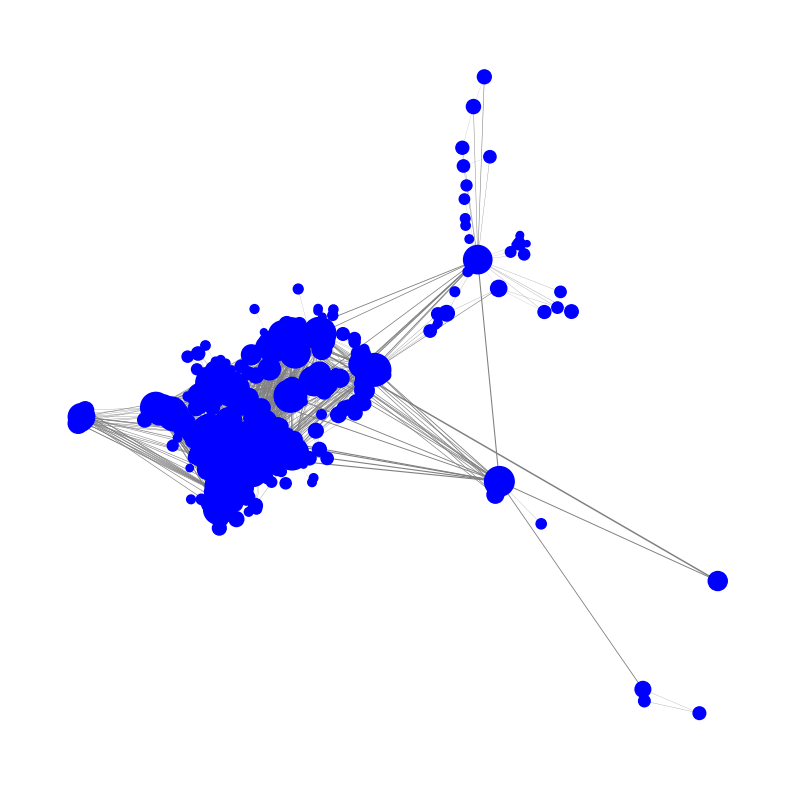

In [32]:
fig=plt.figure(figsize=(10,10))

sizes=[200*G.degree(node,weight='weight')**0.5 for node in G.nodes()] ## Size proportional to strength


positions=nx.kamada_kawai_layout(G,weight='weight')

edge_thickness=[2*G.edges[edge]['weight'] for edge in list(G.edges())] ## Edge thickness proportional to weight
nx.draw_networkx(G,node_size=sizes,pos=positions,edge_color='grey',width=edge_thickness,node_color='blue',with_labels=False,font_size=20)
plt.box(False)

Ideally, nodes positions should have been set according to the geographical coordinates in case they are available

#### c-elegans connectome

In [33]:
G=nx.read_edgelist('../Datasets/C-elegans-frontal.txt')

In [34]:
G.nodes()

NodeView(('11', '0', '26', '69', '71', '83', '114', '12', '1', '19', '27', '44', '72', '112', '115', '126', '6', '2', '8', '13', '15', '18', '28', '29', '30', '32', '33', '38', '39', '43', '81', '116', '7', '3', '31', '37', '46', '66', '75', '76', '10', '4', '5', '16', '24', '42', '34', '73', '79', '80', '100', '9', '14', '17', '47', '74', '48', '77', '20', '35', '78', '113', '89', '45', '21', '22', '25', '23', '40', '36', '41', '49', '53', '55', '65', '67', '90', '99', '105', '119', '123', '127', '50', '54', '56', '68', '86', '91', '98', '104', '120', '124', '128', '51', '57', '106', '121', '52', '58', '64', '70', '82', '84', '87', '107', '122', '88', '94', '93', '129', '59', '60', '92', '61', '95', '125', '62', '63', '101', '117', '118', '110', '111', '108', '109', '85', '97', '130', '102', '103', '96'))

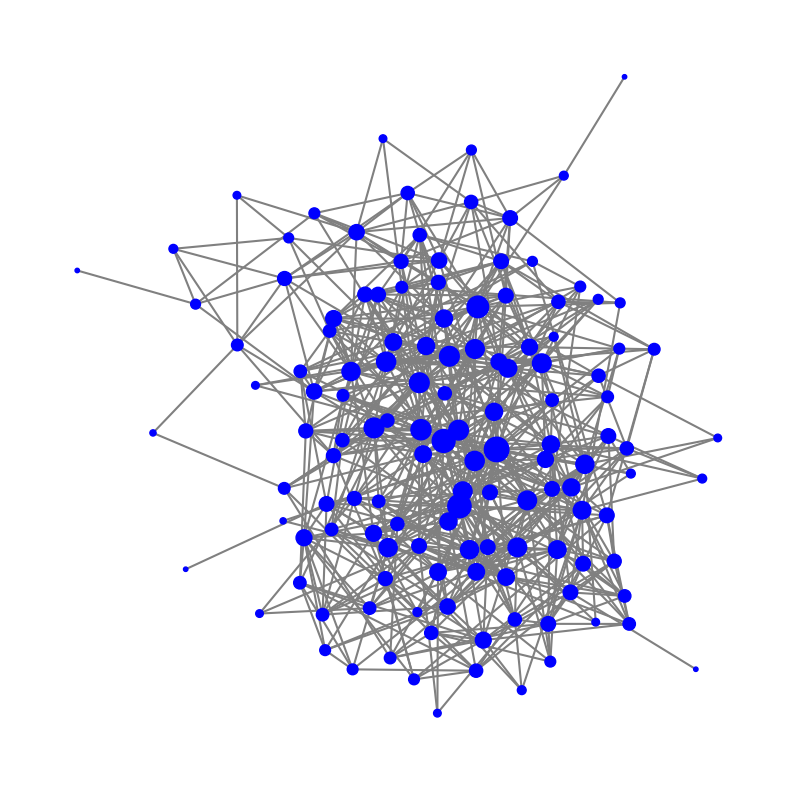

In [35]:

positions=nx.kamada_kawai_layout(G)

## Size proportional to degree again
sizes=[10*G.degree(node) for node in G.nodes()]

## We represent the network fixing the positions.
fig=plt.figure(figsize=(10,10))
nx.draw_networkx(G,node_size=sizes,pos=positions,edge_color='grey',node_color='blue',width=1.5,with_labels=False,font_size=20)
plt.box(False)

Let's fix the position of the nodes (neurons) according to real data

In [36]:
positions_df=pd.read_csv('../Datasets/C-elegans-frontal-meta.csv')

In [37]:
positions_df['node_id']=positions_df['node_id'].astype(str)

In [38]:
positions={}
for node in G.nodes():
    positions[node]=[positions_df[positions_df['node_id']==node]['posx'].values[0],positions_df[positions_df['node_id']==node]['posy'].values[0]]

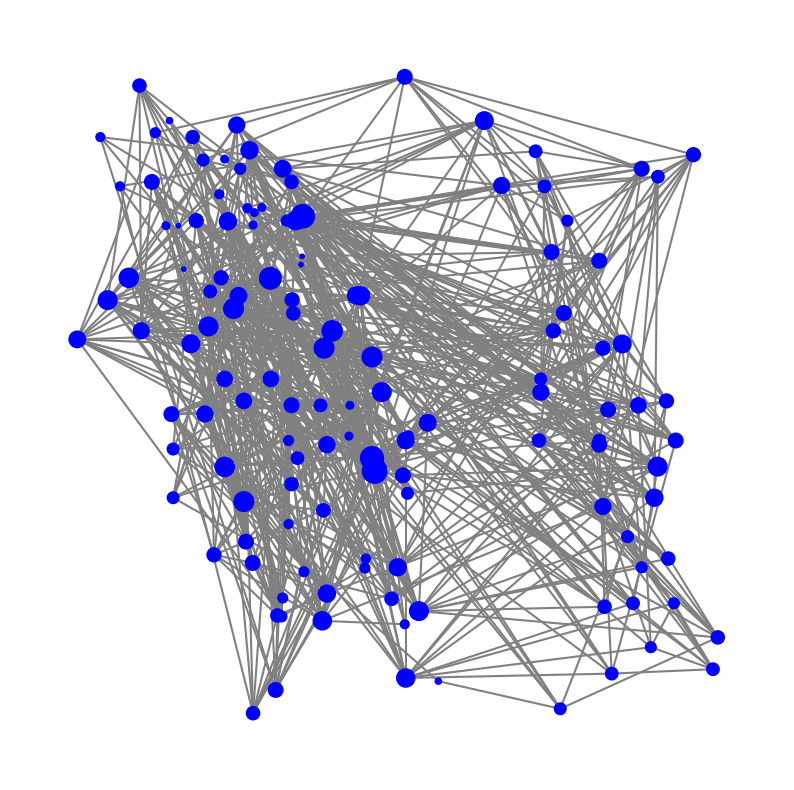

In [39]:
## Size proportional to degree again
sizes=[10*G.degree(node) for node in G.nodes()]

## We represent the network fixing the positions.
fig=plt.figure(figsize=(10,10))
nx.draw_networkx(G,node_size=sizes,pos=positions,edge_color='grey',node_color='blue',width=1.5,with_labels=False,font_size=20)
plt.box(False)